# Feature Block Ablation Study

Tests the full `xgb_with_elo` model with each of the four feature blocks removed one at a time.

| Ablation | Removed block | Remaining |
|----------|--------------|-----------|
| `no_player` | Player injury/availability (126 cols) | Form + Style + Schedule |
| `no_form` | Recent form (10 cols) | Player + Style + Schedule |
| `no_style` | Style/matchup (12 cols) | Player + Form + Schedule |
| `no_schedule` | Rest/travel (12 cols) | Player + Form + Style |

Baseline: `full` = all 160 features with `base_margin = logit(p_elo)`.

Uses identical hyperparameters, walk-forward CV (OOF 2020–2024), and 2025 holdout.

## Section 1 — Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
%matplotlib inline

PROJECT_ROOT = Path("../..").resolve()
GOLD_DIR     = PROJECT_ROOT / "data" / "gold"
OUT_DIR      = PROJECT_ROOT / "data" / "model_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Gold dir:     {GOLD_DIR}")

Project root: C:\Users\arius\Desktop\kalshi_wnba_bot\organized
Gold dir:     C:\Users\arius\Desktop\kalshi_wnba_bot\organized\data\gold


In [2]:
# --- Frozen hyperparameters (identical to forecasting_results) ---
XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "logloss",
    "max_depth":        6,
    "min_child_weight": 3,
    "subsample":        0.8,
    "colsample_bytree": 0.6,
    "reg_lambda":       1.0,
    "reg_alpha":        0.0,
    "gamma":            0.1,
    "learning_rate":    0.02,
    "seed":             42,
    "nthread":         -1,
}
NUM_BOOST_ROUND       = 3000
EARLY_STOPPING_ROUNDS = 150
N_PLAYERS             = 7

CLIP_EPS    = 1e-6
OOF_YEARS   = list(range(2020, 2025))
TRAIN_START = 2015

In [3]:
# --- Feature column definitions ---
PLAYER_MODEL_FEATURES = [
    "m_ewma_pre", "q_pre", "days_since_first_report_pre",
    "days_since_last_dnp_pre", "consec_dnps_pre", "played_last_game_pre",
    "minutes_last_game_pre", "days_since_last_played_pre",
    "injury_present_flag_pre",
]
RECENT_FORM_FEATURES = [
    "net_rtg_ewma_pre", "efg_ewma_pre", "tov_pct_ewma_pre",
    "orb_pct_ewma_pre", "ftr_ewma_pre",
]
STYLE_FEATURES = [
    "off_3pa_rate_pre", "def_3pa_allowed_pre", "off_2pa_rate_pre",
    "def_2pa_allowed_pre", "off_tov_pct_pre", "def_forced_tov_pre",
]
SCHEDULE_FEATURES = [
    "days_rest_pre", "is_b2b_pre", "games_last_4_days_pre",
    "games_last_7_days_pre", "travel_miles_pre", "timezone_shift_hours_pre",
]

def build_feature_cols(n_players):
    """Build full 160-column feature list."""
    cols = []
    for side in ("home", "away"):
        for slot in range(1, n_players + 1):
            for feat in PLAYER_MODEL_FEATURES:
                cols.append(f"{side}_p{slot}_{feat}")
    for feat in RECENT_FORM_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    for feat in STYLE_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    for feat in SCHEDULE_FEATURES:
        cols.append(f"home_{feat}")
        cols.append(f"away_{feat}")
    return cols

def build_block_cols(n_players):
    """Return dict mapping block name -> list of column names."""
    player = []
    for side in ("home", "away"):
        for slot in range(1, n_players + 1):
            for feat in PLAYER_MODEL_FEATURES:
                player.append(f"{side}_p{slot}_{feat}")
    form = []
    for feat in RECENT_FORM_FEATURES:
        form.append(f"home_{feat}")
        form.append(f"away_{feat}")
    style = []
    for feat in STYLE_FEATURES:
        style.append(f"home_{feat}")
        style.append(f"away_{feat}")
    schedule = []
    for feat in SCHEDULE_FEATURES:
        schedule.append(f"home_{feat}")
        schedule.append(f"away_{feat}")
    return {"player": player, "form": form, "style": style, "schedule": schedule}

FEATURE_COLS = build_feature_cols(N_PLAYERS)
BLOCK_COLS   = build_block_cols(N_PLAYERS)

# Define ablation variants: each removes one block
ABLATIONS = {
    "full":        FEATURE_COLS,
    "no_player":   [c for c in FEATURE_COLS if c not in BLOCK_COLS["player"]],
    "no_form":     [c for c in FEATURE_COLS if c not in BLOCK_COLS["form"]],
    "no_style":    [c for c in FEATURE_COLS if c not in BLOCK_COLS["style"]],
    "no_schedule": [c for c in FEATURE_COLS if c not in BLOCK_COLS["schedule"]],
}

for name, cols in ABLATIONS.items():
    print(f"{name:15s}: {len(cols)} features")

full           : 160 features
no_player      : 34 features
no_form        : 150 features
no_style       : 148 features
no_schedule    : 148 features


In [4]:
# --- Data loaders ---
def load_gold(season):
    p = GOLD_DIR / f"game_xgboost_input_{season}_REGPST.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")
    df = pd.read_csv(p)
    df["season"] = df["season"].astype(int)
    cold = (df["home_p1_m_ewma_pre"] == 0) | (df["away_p1_m_ewma_pre"] == 0)
    n_drop = cold.sum()
    if n_drop:
        df = df[~cold].reset_index(drop=True)
        print(f"  [load {season}] dropped {n_drop} cold-start rows")
    return df

def load_range(start, end):
    dfs = []
    for y in range(start, end + 1):
        try:
            dfs.append(load_gold(y))
        except FileNotFoundError as e:
            print(f"  WARNING: {e}")
    return pd.concat(dfs, ignore_index=True).dropna(subset=["home_win", "base_margin"])

# --- Helpers ---
def clip(p):
    return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)

def metrics(y, p):
    p = clip(p)
    return {
        "log_loss":  log_loss(y, p),
        "brier":     brier_score_loss(y, p),
        "accuracy":  accuracy_score(y, (p >= 0.5).astype(int)),
        "n_games":   len(y),
    }

In [5]:
# --- XGBoost fit/predict with nested early stopping ---
def fit_predict_xgb(X_train, y_train, X_es_val, y_es_val,
                     X_test, bm_train, bm_es_val, bm_test,
                     feature_names=None):
    def make_dm(X, y, bm):
        kw = dict(data=X.astype(float), label=y.astype(float),
                  feature_names=feature_names, missing=np.nan)
        kw["base_margin"] = bm.astype(float)
        return xgb.DMatrix(**kw)

    dm_es_train = make_dm(X_train, y_train, bm_train)
    dm_es_val   = make_dm(X_es_val, y_es_val, bm_es_val)

    es_model = xgb.train(
        XGB_PARAMS, dm_es_train,
        num_boost_round=NUM_BOOST_ROUND,
        evals=[(dm_es_val, "val")],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose_eval=False,
    )
    best_round = es_model.best_iteration + 1

    # Retrain on train + es_val for best_round trees
    X_full  = np.vstack([X_train, X_es_val])
    y_full  = np.concatenate([y_train, y_es_val])
    bm_full = np.concatenate([bm_train, bm_es_val])
    dm_full = make_dm(X_full, y_full, bm_full)
    dm_test = make_dm(X_test, np.zeros(len(X_test)), bm_test)

    model = xgb.train(XGB_PARAMS, dm_full, num_boost_round=best_round, verbose_eval=False)
    preds = model.predict(dm_test)
    return clip(preds), best_round

## Section 2 — Walk-Forward OOF Ablation (2020–2024)

For each test year Y and each ablation variant:
- ES-train on 2015..Y-2, ES-val on Y-1 → find `best_round`
- Retrain on 2015..Y-1 for `best_round` trees
- Predict on Y

Also includes `elo` baseline (no XGBoost) for reference.

In [6]:
all_oof = []

for test_year in OOF_YEARS:
    print(f"\n{'='*60}")
    print(f"Fold: test_year = {test_year}")
    print(f"{'='*60}")
    es_val_year = test_year - 1

    es_train_df = load_range(TRAIN_START, es_val_year - 1)
    es_val_df   = load_gold(es_val_year).dropna(subset=["home_win", "base_margin"])
    test_df     = load_gold(test_year).dropna(subset=["home_win", "base_margin"])

    y_test      = test_df["home_win"].values.astype(float)
    bm_es_train = es_train_df["base_margin"].values.astype(float)
    bm_es_val   = es_val_df["base_margin"].values.astype(float)
    bm_test     = test_df["base_margin"].values.astype(float)
    p_elo_test  = clip(test_df["p_elo"].values.astype(float))
    y_es_train  = es_train_df["home_win"].values.astype(float)
    y_es_val    = es_val_df["home_win"].values.astype(float)

    # Elo baseline
    m_elo = metrics(y_test, p_elo_test)
    print(f"  {'elo':15s}  LL={m_elo['log_loss']:.5f}  Brier={m_elo['brier']:.5f}  Acc={m_elo['accuracy']:.3f}")
    for i in range(len(test_df)):
        all_oof.append({
            "game_id": test_df.iloc[i]["game_id"], "season": int(test_df.iloc[i]["season"]),
            "home_win": int(y_test[i]), "model": "elo", "pred_prob": float(p_elo_test[i]),
        })

    # Ablation variants
    for abl_name, abl_cols in ABLATIONS.items():
        avail = [c for c in abl_cols if c in es_train_df.columns]

        X_es_train = es_train_df[avail].values
        X_es_val   = es_val_df[avail].values
        X_test     = test_df[avail].values

        preds, br = fit_predict_xgb(
            X_es_train, y_es_train, X_es_val, y_es_val, X_test,
            bm_es_train, bm_es_val, bm_test, feature_names=avail,
        )
        m = metrics(y_test, preds)
        print(f"  {abl_name:15s}  LL={m['log_loss']:.5f}  Brier={m['brier']:.5f}  Acc={m['accuracy']:.3f}  best_round={br}")

        for i in range(len(test_df)):
            all_oof.append({
                "game_id": test_df.iloc[i]["game_id"], "season": int(test_df.iloc[i]["season"]),
                "home_win": int(y_test[i]), "model": abl_name, "pred_prob": float(preds[i]),
            })

oof_df = pd.DataFrame(all_oof)
print(f"\nTotal OOF rows: {len(oof_df)}")


Fold: test_year = 2020
  [load 2015] dropped 7 cold-start rows
  elo              LL=0.59431  Brier=0.20221  Acc=0.721
  full             LL=0.59524  Brier=0.20263  Acc=0.721  best_round=10
  no_player        LL=0.59477  Brier=0.20243  Acc=0.707  best_round=1
  no_form          LL=0.59755  Brier=0.20360  Acc=0.714  best_round=2
  no_style         LL=0.60337  Brier=0.20687  Acc=0.714  best_round=88
  no_schedule      LL=0.60403  Brier=0.20718  Acc=0.714  best_round=69

Fold: test_year = 2021
  [load 2015] dropped 7 cold-start rows
  elo              LL=0.60669  Brier=0.21111  Acc=0.646
  full             LL=0.60520  Brier=0.21045  Acc=0.665  best_round=63
  no_player        LL=0.60706  Brier=0.21125  Acc=0.646  best_round=2
  no_form          LL=0.60669  Brier=0.21106  Acc=0.646  best_round=1
  no_style         LL=0.60712  Brier=0.21129  Acc=0.641  best_round=5
  no_schedule      LL=0.60601  Brier=0.21080  Acc=0.646  best_round=1

Fold: test_year = 2022
  [load 2015] dropped 7 cold-sta

### OOF Summary Table

In [7]:
MODEL_ORDER = ["elo", "full", "no_player", "no_form", "no_style", "no_schedule"]
MODEL_LABELS = {
    "elo":         "Elo Only",
    "full":        "Full (all blocks)",
    "no_player":   "− Player block",
    "no_form":     "− Form block",
    "no_style":    "− Style block",
    "no_schedule": "− Schedule block",
}

rows = []
for model_name in MODEL_ORDER:
    sub = oof_df[oof_df["model"] == model_name]
    m = metrics(sub["home_win"].values, sub["pred_prob"].values)
    rows.append({"Model": MODEL_LABELS[model_name], **m})

summary_oof = pd.DataFrame(rows)
summary_oof["Δ LL vs full"] = summary_oof["log_loss"] - summary_oof.loc[summary_oof["Model"] == "Full (all blocks)", "log_loss"].values[0]
print("OOF 2020–2024 (pooled)")
print(summary_oof.to_string(index=False, float_format="%.5f"))

OOF 2020–2024 (pooled)
            Model  log_loss   brier  accuracy  n_games  Δ LL vs full
         Elo Only   0.60216 0.20724   0.67771     1117       0.00277
Full (all blocks)   0.59939 0.20550   0.69472     1117       0.00000
   − Player block   0.60249 0.20739   0.67771     1117       0.00309
     − Form block   0.60218 0.20693   0.68308     1117       0.00279
    − Style block   0.60434 0.20818   0.68308     1117       0.00495
 − Schedule block   0.60171 0.20689   0.68577     1117       0.00232


### OOF Per-Fold Breakdown

In [8]:
fold_rows = []
for year in OOF_YEARS:
    for model_name in MODEL_ORDER:
        sub = oof_df[(oof_df["model"] == model_name) & (oof_df["season"] == year)]
        if len(sub) == 0:
            continue
        m = metrics(sub["home_win"].values, sub["pred_prob"].values)
        fold_rows.append({"year": year, "model": MODEL_LABELS[model_name], "log_loss": m["log_loss"],
                          "brier": m["brier"], "accuracy": m["accuracy"], "n": m["n_games"]})

fold_df = pd.DataFrame(fold_rows)
pivot = fold_df.pivot(index="model", columns="year", values="log_loss")
pivot = pivot.reindex([MODEL_LABELS[m] for m in MODEL_ORDER])
print("Log Loss by fold")
print(pivot.to_string(float_format="%.5f"))

Log Loss by fold
year                 2020    2021    2022    2023    2024
model                                                    
Elo Only          0.59431 0.60669 0.61294 0.59912 0.59615
Full (all blocks) 0.59524 0.60520 0.60965 0.59841 0.58871
− Player block    0.59477 0.60706 0.61303 0.59947 0.59656
− Form block      0.59755 0.60669 0.61608 0.59682 0.59382
− Style block     0.60337 0.60712 0.62180 0.59646 0.59458
− Schedule block  0.60403 0.60601 0.61002 0.59801 0.59307


### OOF Log Loss Bar Chart

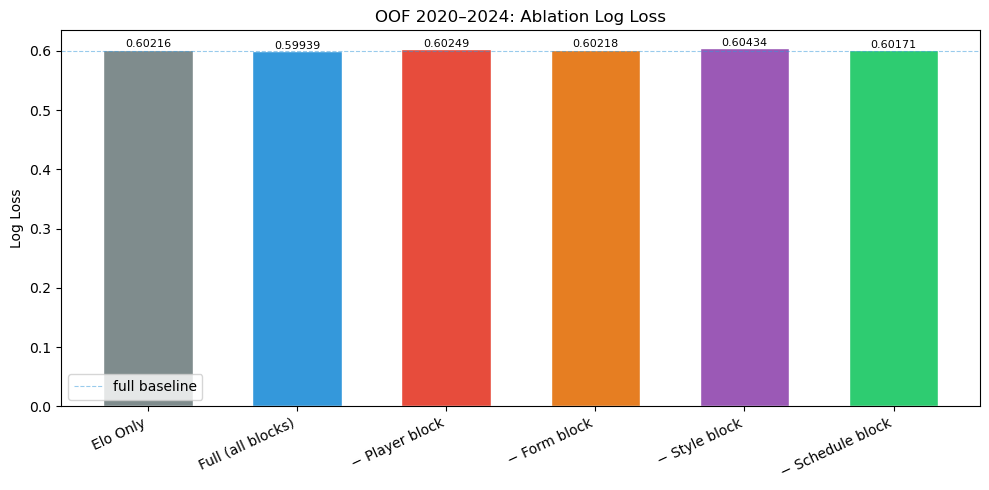

In [9]:
COLORS = {
    "elo": "#7f8c8d", "full": "#3498db",
    "no_player": "#e74c3c", "no_form": "#e67e22",
    "no_style": "#9b59b6", "no_schedule": "#2ecc71",
}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODEL_ORDER))
vals = []
for mn in MODEL_ORDER:
    sub = oof_df[oof_df["model"] == mn]
    vals.append(log_loss(sub["home_win"], clip(sub["pred_prob"])))

bars = ax.bar(x, vals, color=[COLORS[m] for m in MODEL_ORDER], edgecolor="white", width=0.6)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], rotation=25, ha="right")
ax.set_ylabel("Log Loss")
ax.set_title("OOF 2020–2024: Ablation Log Loss")
ax.axhline(vals[1], color=COLORS["full"], ls="--", lw=0.8, alpha=0.5, label="full baseline")

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0005, f"{v:.5f}", ha="center", va="bottom", fontsize=8)

ax.legend()
plt.tight_layout()
plt.show()

## Section 3 — 2025 Holdout Ablation

Train on all 2015–2024, ES-val on 2024, predict 2025.

In [10]:
# Load holdout data
es_train_h_df = load_range(TRAIN_START, 2023)
es_val_h_df   = load_gold(2024).dropna(subset=["home_win", "base_margin"])
holdout_df    = load_gold(2025).dropna(subset=["home_win", "base_margin"])

y_holdout     = holdout_df["home_win"].values.astype(float)
bm_holdout    = holdout_df["base_margin"].values.astype(float)
p_elo_holdout = clip(holdout_df["p_elo"].values.astype(float))
bm_es_tr_h    = es_train_h_df["base_margin"].values.astype(float)
bm_es_val_h   = es_val_h_df["base_margin"].values.astype(float)
y_es_tr_h     = es_train_h_df["home_win"].values.astype(float)
y_es_val_h    = es_val_h_df["home_win"].values.astype(float)

holdout_rows = []

# Elo baseline
m_elo = metrics(y_holdout, p_elo_holdout)
print(f"{'elo':15s}  LL={m_elo['log_loss']:.5f}  Brier={m_elo['brier']:.5f}  Acc={m_elo['accuracy']:.3f}")
for i in range(len(holdout_df)):
    holdout_rows.append({
        "game_id": holdout_df.iloc[i]["game_id"], "season": 2025,
        "home_win": int(y_holdout[i]), "model": "elo", "pred_prob": float(p_elo_holdout[i]),
    })

# Ablation variants
for abl_name, abl_cols in ABLATIONS.items():
    avail = [c for c in abl_cols if c in es_train_h_df.columns]

    X_es_tr  = es_train_h_df[avail].values
    X_es_val = es_val_h_df[avail].values
    X_hold   = holdout_df[avail].values

    preds, br = fit_predict_xgb(
        X_es_tr, y_es_tr_h, X_es_val, y_es_val_h, X_hold,
        bm_es_tr_h, bm_es_val_h, bm_holdout, feature_names=avail,
    )
    m = metrics(y_holdout, preds)
    print(f"{abl_name:15s}  LL={m['log_loss']:.5f}  Brier={m['brier']:.5f}  Acc={m['accuracy']:.3f}  best_round={br}")

    for i in range(len(holdout_df)):
        holdout_rows.append({
            "game_id": holdout_df.iloc[i]["game_id"], "season": 2025,
            "home_win": int(y_holdout[i]), "model": abl_name, "pred_prob": float(preds[i]),
        })

holdout_pred_df = pd.DataFrame(holdout_rows)
print(f"\nTotal holdout rows: {len(holdout_pred_df)}")

  [load 2015] dropped 7 cold-start rows
elo              LL=0.61510  Brier=0.21317  Acc=0.668
full             LL=0.61215  Brier=0.21123  Acc=0.674  best_round=88
no_player        LL=0.61443  Brier=0.21284  Acc=0.661  best_round=1
no_form          LL=0.62514  Brier=0.21580  Acc=0.655  best_round=113
no_style         LL=0.61711  Brier=0.21370  Acc=0.658  best_round=68
no_schedule      LL=0.62587  Brier=0.21483  Acc=0.671  best_round=302

Total holdout rows: 1860


### Holdout Summary Table

In [11]:
rows = []
for model_name in MODEL_ORDER:
    sub = holdout_pred_df[holdout_pred_df["model"] == model_name]
    m = metrics(sub["home_win"].values, sub["pred_prob"].values)
    rows.append({"Model": MODEL_LABELS[model_name], **m})

summary_hold = pd.DataFrame(rows)
summary_hold["Δ LL vs full"] = summary_hold["log_loss"] - summary_hold.loc[summary_hold["Model"] == "Full (all blocks)", "log_loss"].values[0]
print("2025 Holdout")
print(summary_hold.to_string(index=False, float_format="%.5f"))

2025 Holdout
            Model  log_loss   brier  accuracy  n_games  Δ LL vs full
         Elo Only   0.61510 0.21317   0.66774      310       0.00295
Full (all blocks)   0.61215 0.21123   0.67419      310       0.00000
   − Player block   0.61443 0.21284   0.66129      310       0.00228
     − Form block   0.62514 0.21580   0.65484      310       0.01299
    − Style block   0.61711 0.21370   0.65806      310       0.00496
 − Schedule block   0.62587 0.21483   0.67097      310       0.01372


### Combined OOF + Holdout Bar Chart

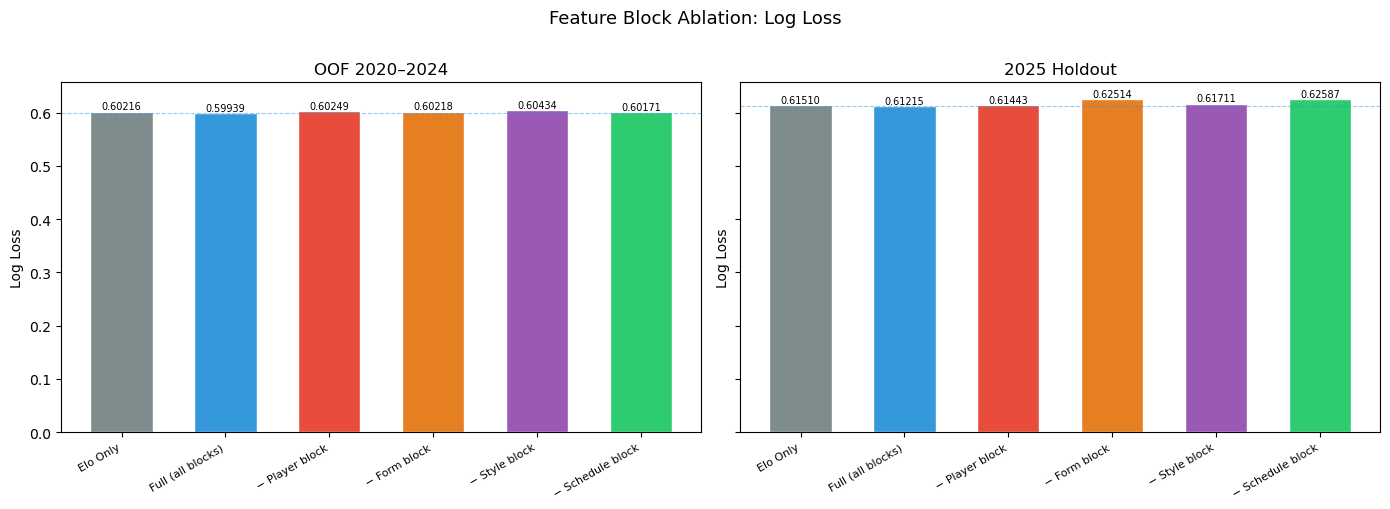

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, df_src) in zip(axes, [("OOF 2020–2024", oof_df), ("2025 Holdout", holdout_pred_df)]):
    x = np.arange(len(MODEL_ORDER))
    vals = []
    for mn in MODEL_ORDER:
        sub = df_src[df_src["model"] == mn]
        vals.append(log_loss(sub["home_win"], clip(sub["pred_prob"])))

    bars = ax.bar(x, vals, color=[COLORS[m] for m in MODEL_ORDER], edgecolor="white", width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Log Loss")
    ax.set_title(title)
    ax.axhline(vals[1], color=COLORS["full"], ls="--", lw=0.8, alpha=0.5)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.0003, f"{v:.5f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Feature Block Ablation: Log Loss", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()